# Example use-case: Cosmological gravitational-wave merger rate density

The original project this codebase was designed for was to calculate the cosmological binary black-hole (BHBH) gravitational-wave merger and supernova transient rate density ([Hendriks et al. 2023](https://doi.org/10.1093/mnras/stad2857)).
 
The following section will flesh out the steps to perform a similar calculation.

Several ingredients are necessary here:
- population-synthesis results that contain BHBH systems
- A cosmological star formation rate density

This convolution is an event-based convolution by integration.

In [1]:
import os
import pkg_resources
import copy

import h5py
import pandas as pd
import numpy as np
import astropy.units as u

from syntheticstellarpopconvolve import convolve
from syntheticstellarpopconvolve import default_convolution_config
from syntheticstellarpopconvolve.general_functions import temp_dir

TMP_DIR = temp_dir("notebooks", "notebook_example_GW_merger_rate_density", clean_path=True)
VERBOSITY = 0

/tmp/ipykernel_1404704/4159766026.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Lets start with loading some data and see which metallicities are present. This data is generated by a grid-based population-synthesis evolution at a series of fixed metallicities.

This package contains a minimized version of the data for this usecase, but if the environment variable `EXAMPLE_DATA_USECASE_GW_FILENAME` points to the full dataset it will use that.

In [2]:
data_filename = os.getenv('EXAMPLE_DATA_USECASE_GW_FILENAME')
example_usecase_GW_events_filename = data_filename if data_filename is not None else pkg_resources.resource_filename(
    "syntheticstellarpopconvolve",
    "example_data/example_data_usecase_gw.h5"
)

example_usecase_GW_events_data = pd.read_hdf(example_usecase_GW_events_filename,  key='data/combined_dataframes')
example_usecase_GW_events_data['delay_time_values_in_years'] = example_usecase_GW_events_data['formation_time_values_in_years']+example_usecase_GW_events_data['merger_time_values_in_years']

#
print(example_usecase_GW_events_data.columns)
log10_metallicity_centers = np.log10(example_usecase_GW_events_data['metallicity'].unique())
print(log10_metallicity_centers)
stepsize = np.diff(log10_metallicity_centers)
log10_bin_edges = np.concatenate([log10_metallicity_centers[:-1]-stepsize/2, log10_metallicity_centers[-2:]+stepsize[:2]/2])

Index(['uuid', 'mass_1', 'zams_mass_1', 'mass_2', 'zams_mass_2',
       'stellar_type_1', 'stellar_type_2', 'metallicity', 'eccentricity',
       'period', 'zams_period', 'fallback_1', 'fallback_2', 'random_seed',
       'undergone_ppisn_1', 'undergone_ppisn_2', 'comenv_counter',
       'stable_rlof_counter', 'undergone_CE_with_HG_donor',
       'undergone_CE_with_MS_donor', 'formation_time_values_in_years',
       'merger_time_values_in_years', 'number_per_solar_mass_values',
       'local_index', 'delay_time_values_in_years'],
      dtype='object')
[-1.4        -1.62727273 -1.85454545 -2.08181818 -2.30909091 -2.53636364
 -2.76363636 -2.99090909 -3.21818182 -3.44545455 -3.67272727 -3.9       ]


Next up is to set up the star formation info. In this example we use a redshift-based cosmological starformation history, and an accompanying metallicity distribution, both described in [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51). 

The metallicity distribution of [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51) is defined in log Z, and thus we will need to either convert it to a different base, or provide our input metallicity values in log Z as well.

We will first display a high resolution version of this metallicity-dependent star formation rate history, and then configure it to our needs.

ValueError: unsupported format character '$' (0x24) at index 6

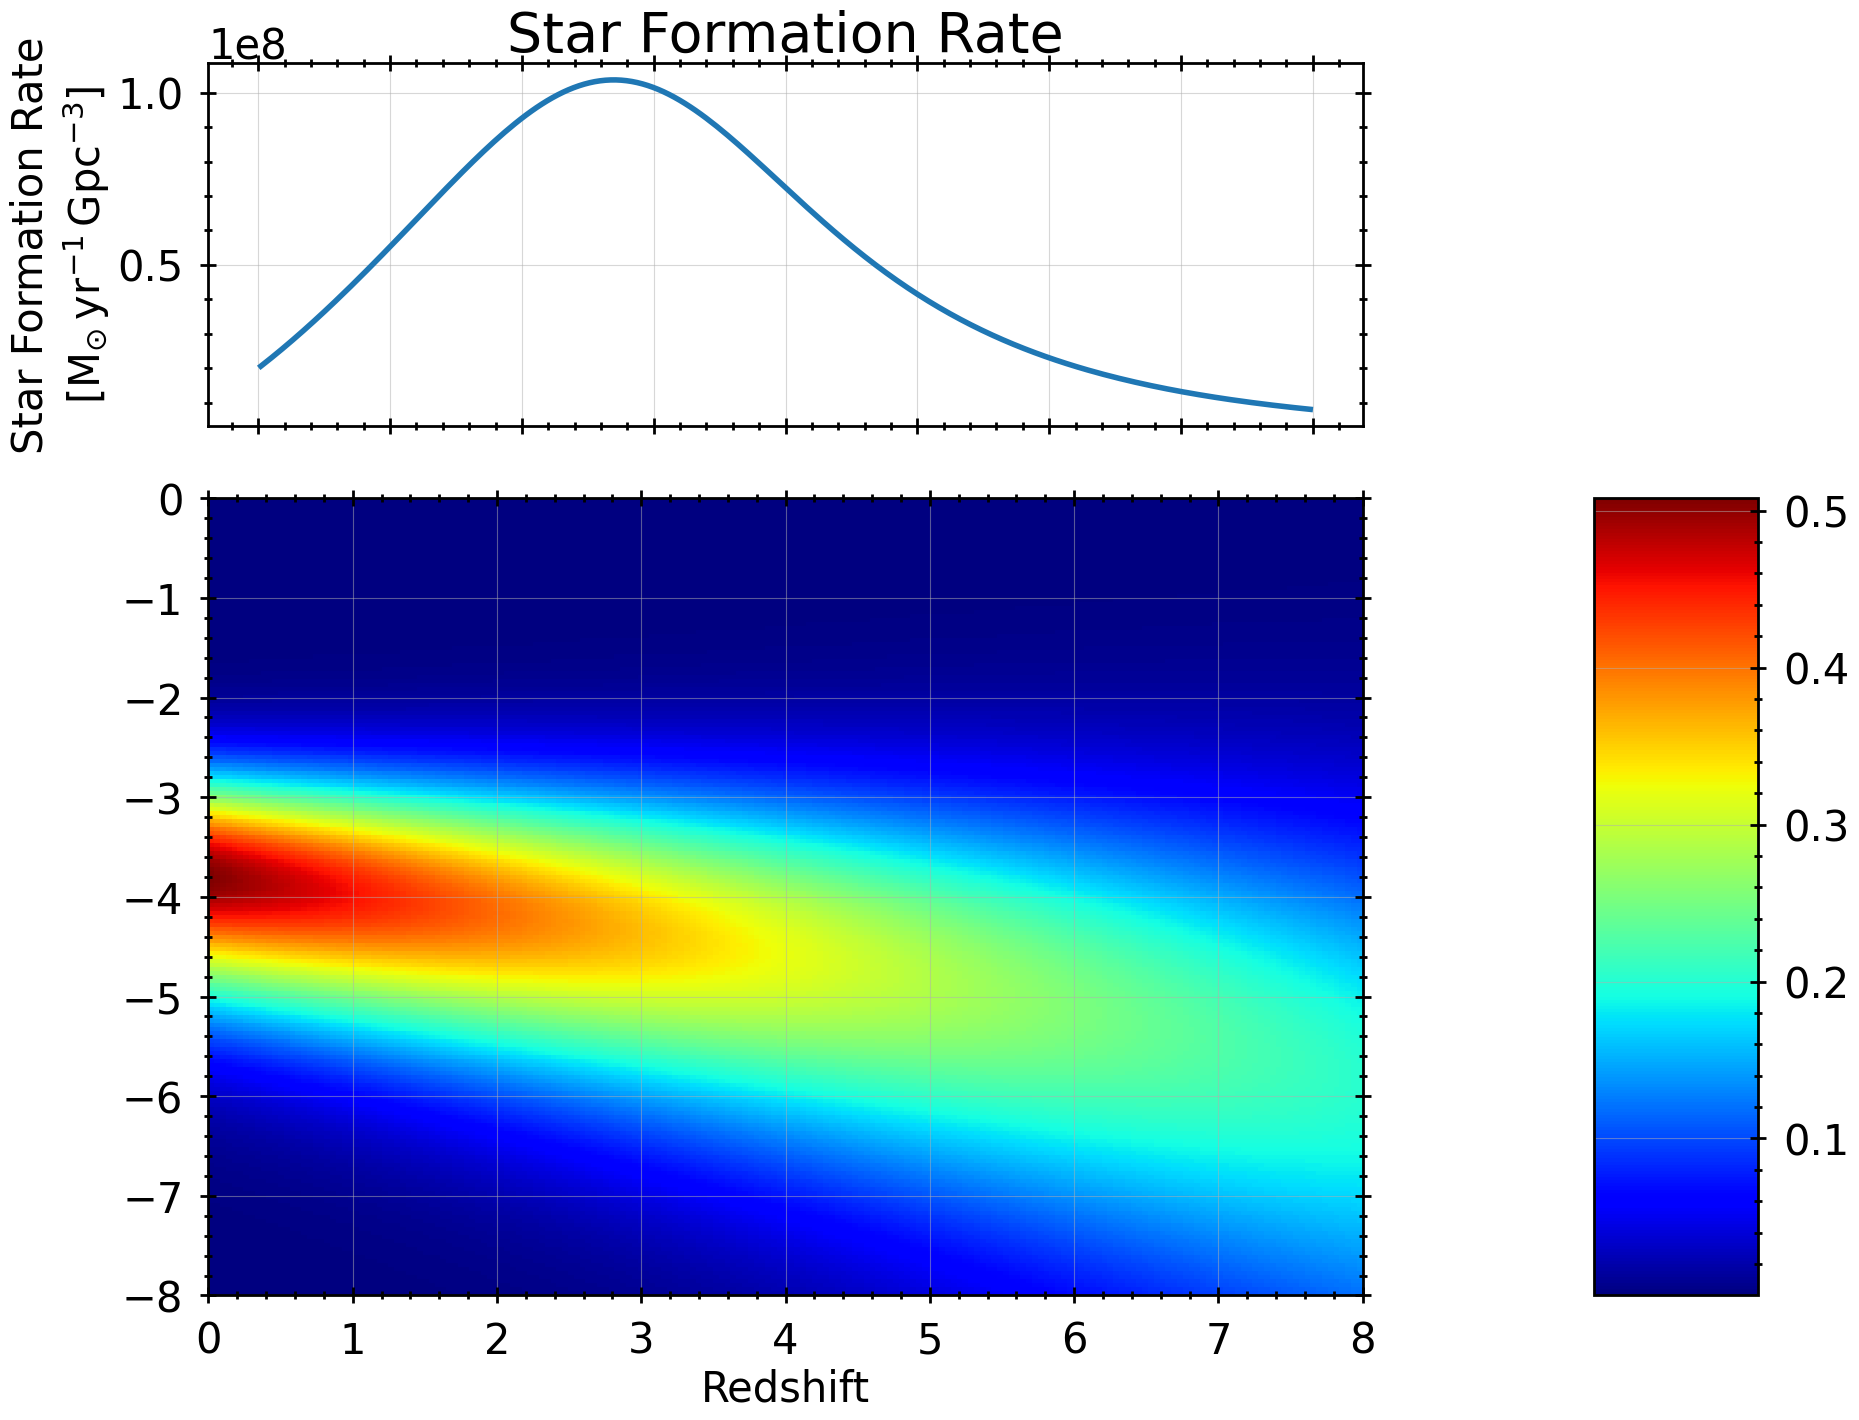

In [3]:
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022
from syntheticstellarpopconvolve.general_functions import calculate_bincenters
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict

# Set up redshift bin info
redshift_bin_edges = np.linspace(0, 8, 200); redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

# Set up metallicity bin info
log_metallicity_bin_edges = np.linspace(-8, 0, 200); log_metallicity_bin_centers = calculate_bincenters(log_metallicity_bin_edges)

#
sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

#
dpdlogZ = metallicity_distribution_vanSon2022(
    log_metallicity_centers=log_metallicity_bin_centers,
    redshifts=redshift_bin_centers,
)

sample_sfr_dict = {
    "redshift_bin_edges": redshift_bin_edges,
    "starformation_rate_array": sfr,
    "metallicity_bin_edges": log_metallicity_bin_edges,
    "metallicity_distribution_array": dpdlogZ.T,  # We need to transpose!
}

plot_sfr_dict(sample_sfr_dict, time_type="redshift", return_axis_dict=False)


In [6]:

############
# configure the time-bins
timebin_stepsize = 0.5

time_bins = np.arange(
    1e-6 - 0.5 * timebin_stepsize,
    10
    + 0.5 * timebin_stepsize,
    timebin_stepsize,
)
time_centers = (
    time_bins[1:] + time_bins[:-1]
) / 2

###############
# Get sfr values
sfr_values = starformation_rate_distribution_vanSon2023(
    np.array(time_centers),
)

print(sfr_values)


# metallicity_distribution_vanSon2022(metallicities, redshifts)

# ###############
# # Calculate the metallicity distribution dP/dlogZ grid
# dPdlogZ, metallicities, _ = metallicity_distribution_vanSon2022(
#     np.array(convolution_configuration["time_centers"]),
#     0,
#     -8,
#     # metallicity distribution settings for vanSon21
#     **{
#         "mu0": 0.025,
#         "muz": -0.05,
#         "sigma_0": 1.125,
#         "sigma_z": 0.05,
#         "alpha": -1.77,
#     }
#     step_logZ=0.05,
# )

# # Calculate full probability
# P = dPdlogZ

# # Multiply by sfr:
# MSSFR = (sfr_values * P.T).T.value
# X, Y = np.meshgrid(convolution_configuration["time_centers"], metallicities)

[0.01999704 0.03638613 0.0552961  0.07511947 0.09261984 0.10279241
 0.10150814 0.08957846 0.07244415 0.05553    0.04151335 0.03084275
 0.02301533 0.01734061 0.01322099 0.01020671 0.00797712 0.00630804
 0.00504327 0.00407346] solMass / (yr Mpc3)


Now that we have set up the star formation information and loaded the input data, we can combine everything into the convolution config

In [16]:
# Assign filenames
input_hdf5_filename = os.path.join(TMP_DIR, "input_hdf5.h5")
output_hdf5_filename = os.path.join(TMP_DIR, "output_hdf5.h5")

# Open input file
input_hdf5_file = h5py.File(input_hdf5_filename, "w")

# Create groups main
input_hdf5_file.create_group("input_data")
input_hdf5_file.create_group("config")

# add group for events
input_hdf5_file.create_group("input_data/events")

# close
input_hdf5_file.close()

# store the data frame in the hdf5file
example_usecase_GW_events_data.to_hdf(input_hdf5_filename, key="input_data/events/example_GW_merger_rate_density")

# Some general configuration
convolution_config = copy.copy(default_convolution_config)
convolution_config["input_filename"] = input_hdf5_filename
convolution_config["output_filename"] = output_hdf5_filename
convolution_config["tmp_dir"] = TMP_DIR
convolution_config["redshift_interpolator_data_output_filename"] = os.path.join(
    TMP_DIR, "interpolator_dict.p"
)
convolution_config["multiply_by_time_binsize"] = False

# convolution instructions
convolution_config["convolution_instructions"] = [
    {
        "input_data_type": "event",
        "convolution_type": "integration",
        "input_data_name": "example_GW_merger_rate_density",
        "output_data_name": "intrinsic",
        "ignore_metallicity": False,
        "data_column_dict": {
            # required
            "normalized_yield": "number_per_solar_mass_values",
            "delay_time": {"column_name": "delay_time_values_in_years", "unit": u.yr},
        },
    },
]

#
convolution_config["time_type"] = "redshift"

# configure the target convolution times. In this case we only want to model the rate at redshift ~0, so its a simple set up
convolution_config["convolution_redshift_bin_edges"] = np.array([0, 0.25])

# # store
# convolution_config["SFR_info"] = sfr_dict

# input_hdf5_file = h5py.File(input_hdf5_filename, "r")

# # convolve
# convolve(config=convolution_config)


With the full datasets for .. availble on https://zenodo.org/records/8083112, and a better resolved convolution, we can recreate the following figures